In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)
from tensorflow.keras.layers import Bidirectional, LSTM, Dense

from tensorflow.keras.optimizers import (
    Adam,
    RMSprop
)

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv(
    "/content/drive/MyDrive/pjm_processed.csv",
    parse_dates=["timestamp"]
)

In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")

df = df.reset_index(drop=True)

print(df.shape)
print(df.head())

(145224, 18)
            timestamp   demand  hour  day_of_week  month  day  week  year  \
0 2002-01-08 01:00:00  29445.0     1            1      1    8     2  2002   
1 2002-01-08 02:00:00  28670.0     2            1      1    8     2  2002   
2 2002-01-08 03:00:00  28375.0     3            1      1    8     2  2002   
3 2002-01-08 04:00:00  28542.0     4            1      1    8     2  2002   
4 2002-01-08 05:00:00  29261.0     5            1      1    8     2  2002   

   is_weekend    lag_1   lag_48  lag_168  rolling_mean_24  rolling_mean_168  \
0           0  31187.0  27100.0  30393.0     33452.583333      32519.511905   
1           0  29445.0  26097.0  29265.0     33560.208333      32513.869048   
2           0  28670.0  25793.0  28357.0     33672.458333      32510.327381   
3           0  28375.0  25657.0  27899.0     33786.375000      32510.434524   
4           0  28542.0  25778.0  28057.0     33906.208333      32514.261905   

   rolling_std_24  rolling_std_168    period  lag

In [5]:
df["rolling_mean_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .mean()
)

df["rolling_std_24"] = (
    df["demand"]
    .shift(1)
    .rolling(24)
    .std()
)

df["rolling_mean_168"] = (
    df["demand"]
    .shift(1)
    .rolling(168)
    .mean()
)

df["rolling_std_168"] = (
    df["demand"]
    .shift(1)
    .rolling(168)
    .std()
)

In [6]:
df = df.dropna().reset_index(drop=True)

In [7]:
print(df.isna().sum().sum())

0


In [8]:
test_size = int(len(df) * 0.20)

test_start = len(df) - test_size

remaining = df.iloc[:test_start]

test = df.iloc[test_start:]

In [9]:
validation_hours = 30 * 24

val_start = len(remaining) - validation_hours

train = remaining.iloc[:val_start]

validation = remaining.iloc[val_start:]

In [10]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (115325, 18)
Validation: (720, 18)
Test: (29011, 18)


In [11]:
print(
    "Train:",
    train["timestamp"].min(),
    "to",
    train["timestamp"].max()
)

print(
    "Validation:",
    validation["timestamp"].min(),
    "to",
    validation["timestamp"].max()
)

print(
    "Test:",
    test["timestamp"].min(),
    "to.",
    test["timestamp"].max()
)

Train: 2002-01-15 01:00:00 to 2015-03-13 05:00:00
Validation: 2015-03-13 06:00:00 to 2015-04-12 05:00:00
Test: 2015-04-12 06:00:00 to. 2018-08-03 00:00:00


In [12]:
features = [
    "demand",
    "lag_1",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_24",
    "rolling_std_24",
    "rolling_mean_168",
    "rolling_std_168"
]
target_column = "demand"

In [13]:
feature_scaler = MinMaxScaler()

train_scaled = feature_scaler.fit_transform(
    train[features]
)

validation_scaled = feature_scaler.transform(
    validation[features]
)

test_scaled = feature_scaler.transform(
    test[features]
)

In [14]:
target_scaler = MinMaxScaler()

target_train_scaled = target_scaler.fit_transform(
    train[["demand"]]
)

target_validation_scaled = target_scaler.transform(
    validation[["demand"]]
)

target_test_scaled = target_scaler.transform(
    test[["demand"]]
)

In [15]:
def create_multivariate_sequences(
    X_data,
    y_data,
    input_length=168,
    output_length=24
):

    X = []
    y = []

    for i in range(
        len(X_data) - input_length - output_length + 1
    ):

        X.append(
            X_data[
                i:i + input_length
            ]
        )

        y.append(
            y_data[
                i + input_length:
                i + input_length + output_length
            ]
        )

    return np.array(X), np.array(y)

In [16]:
X_train, y_train = create_multivariate_sequences(
    train_scaled,
    target_train_scaled,
    input_length=168,
    output_length=24
)

In [17]:
y_train = y_train.reshape(
    y_train.shape[0],
    24
)

In [18]:
test_X_input = np.concatenate([
    validation_scaled[-168:],
    test_scaled
])

test_y_input = np.concatenate([
    target_validation_scaled[-168:],
    target_test_scaled
])

In [19]:
X_test, y_test = create_multivariate_sequences(
    test_X_input,
    test_y_input,
    input_length=168,
    output_length=24
)

In [20]:
y_test = y_test.reshape(
    y_test.shape[0],
    24
)

In [21]:
# Validation sequences

val_X_input = np.concatenate([
    train_scaled[-168:],
    validation_scaled
])

val_y_input = np.concatenate([
    target_train_scaled[-168:],
    target_validation_scaled
])

X_val, y_val = create_multivariate_sequences(
    val_X_input,
    val_y_input,
    input_length=168,
    output_length=24
)

y_val = y_val.reshape(
    y_val.shape[0],
    24
)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_val: (697, 168, 9)
y_val: (697, 24)


In [22]:
#evaluation func
def evaluate_forecast(y_true, y_pred):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs(
            (y_true - y_pred) /
            np.where(y_true == 0, 1, y_true)
        )
    ) * 100

    r2 = r2_score(
        y_true,
        y_pred
    )

    bias = np.mean(
        y_pred - y_true
    )

    return mae, mse, rmse, mape, r2, bias

In [23]:
def inverse_target(data):

    original_shape = data.shape

    data = data.reshape(-1, 1)

    data = target_scaler.inverse_transform(
        data
    )

    return data.reshape(original_shape)

In [24]:
def build_BI_LSTM_baseline():

# BI_LSTM
    model = Sequential([
        Bidirectional(
            LSTM(128),
            input_shape=(168, 9)
        ),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [25]:
#Early_stop
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [26]:
BI_LSTM_features = build_BI_LSTM_baseline()

history_features = BI_LSTM_features.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=15,
    batch_size=64,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - loss: 0.0031 - val_loss: 0.0017
Epoch 2/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - loss: 0.0017 - val_loss: 0.0015
Epoch 3/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 4/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 5/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0014 - val_loss: 0.0012
Epoch 6/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 8/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 9/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 10/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0011 - val_loss: 0.0013


In [27]:
pred_features = BI_LSTM_features.predict(
    X_test,
    verbose=0
)

In [28]:
pred_features = inverse_target(
    pred_features
)

actual_test = inverse_target(
    y_test
)

In [ ]:
model.save(
    "final_BI_LSTM_forecasting_model11.keras"
)

NameError: name 'model' is not defined

In [29]:
metrics = evaluate_forecast(
    actual_test,
    pred_features
)

features_result = {
    "Experiment": "BI_LSTM + Lag + Rolling Features",

    "MAE": metrics[0],

    "MSE": metrics[1],

    "RMSE": metrics[2],

    "MAPE": metrics[3],

    "R2": metrics[4],

    "Bias": metrics[5]
}

features_result

{'Experiment': 'BI_LSTM + Lag + Rolling Features',
 'MAE': 1401.797969416134,
 'MSE': 3973651.71816628,
 'RMSE': np.float64(1993.402046293291),
 'MAPE': np.float64(4.473693866595376),
 'R2': 0.9055965825032463,
 'Bias': np.float64(348.6891147744595)}

In [32]:
results = []

results.append({
    "Experiment": "Phase 5 Baseline BI_LSTM",

    "MAE": 1340.036036,

    "MSE": 3734291,

    "RMSE": 1932.508982,

    "MAPE": 4.253224,

    "R2": 0.911292,

    "Bias": 247.006106
})

In [31]:
results.pop(0)

{'Experiment': 'Phase 5 Baseline BI_LSTM',
 'MAE': 1364.036036,
 'MSE': 3715291,
 'RMSE': 1927.508982,
 'MAPE': 4.343224,
 'R2': 0.911742,
 'Bias': 331.006106}

In [33]:
results.append(
    features_result
)

In [34]:
improvement_df = pd.DataFrame(
    results
)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline BI_LSTM,1340.036036,3.734291e+06,1932.508982,4.253224,0.911292,247.006106
1,BI_LSTM + Lag + Rolling Features,1401.797969,3.973652e+06,1993.402046,4.473694,0.905597,348.689115


In [36]:
baseline_rmse = 1932.508982

current_rmse = features_result["RMSE"]

rmse_improvement = (
    (baseline_rmse - current_rmse)
    / baseline_rmse
) * 100

print(
    f"RMSE Improvement: {rmse_improvement:.2f}%"
)

RMSE Improvement: -3.15%


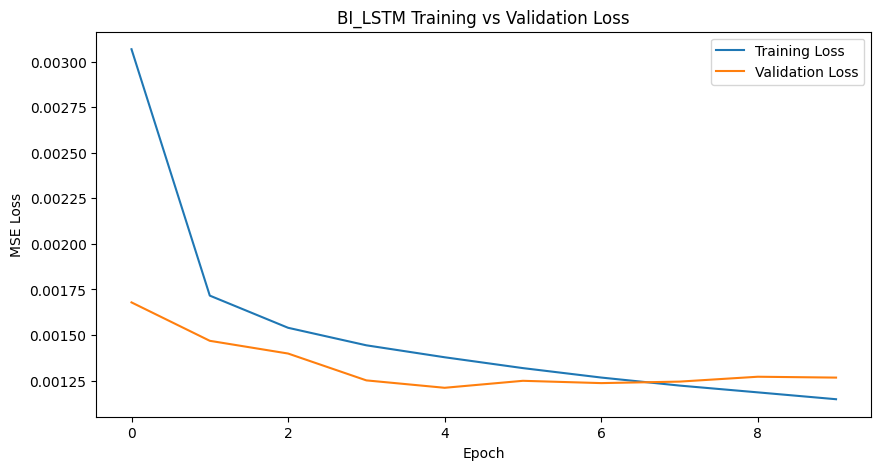

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_features.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_features.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "BI_LSTM Training vs Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.show()

In [39]:
#Build BI_LSTM + Dropout
from tensorflow.keras.layers import Dropout
def build_BI_LSTM_dropout():

    model = Sequential([
        Bidirectional(
            LSTM(128),
            input_shape=(168, 9)
        ),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [40]:
BI_LSTM_dropout = build_BI_LSTM_dropout()

history_dropout = BI_LSTM_dropout.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - loss: 0.0031 - val_loss: 0.0019
Epoch 2/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - loss: 0.0018 - val_loss: 0.0016
Epoch 3/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 4/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 5/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0014 - val_loss: 0.0014


In [41]:
pred_dropout = BI_LSTM_dropout.predict(
    X_test,
    verbose=0
)

pred_dropout = inverse_target(pred_dropout)

metrics = evaluate_forecast(
    actual_test,
    pred_dropout
)

dropout_result = {
    "Experiment": "BI_LSTM + Lag + Rolling + Dropout",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

dropout_result

{'Experiment': 'BI_LSTM + Lag + Rolling + Dropout',
 'MAE': 1665.8944620931056,
 'MSE': 5093779.064363718,
 'RMSE': np.float64(2256.9401995541925),
 'MAPE': np.float64(5.375731846325758),
 'R2': 0.8789853299294034,
 'Bias': np.float64(554.8974897074867)}

In [42]:
results.append(dropout_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline BI_LSTM,1340.036036,3.734291e+06,1932.508982,4.253224,0.911292,247.006106
1,BI_LSTM + Lag + Rolling Features,1401.797969,3.973652e+06,1993.402046,4.473694,0.905597,348.689115
2,BI_LSTM + Lag + Rolling + Dropout,1665.894462,5.093779e+06,2256.940200,5.375732,0.878985,554.897490


In [43]:
#bATCH nORMALIZATION
from tensorflow.keras.layers import BatchNormalization
def build_BI_LSTM_batchnorm():

    model = Sequential([
        Bidirectional(
            LSTM(128),
            input_shape=(168, 9)
        ),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [44]:
BI_LSTM_batchnorm = build_BI_LSTM_batchnorm()

history_batchnorm = BI_LSTM_batchnorm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 55s 15ms/step - loss: 0.0025 - val_loss: 0.0017
Epoch 2/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 0.0016 - val_loss: 0.0017
Epoch 3/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 4/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 5/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 6/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 7/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 8/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 9/15
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 0.0011 - val_loss: 0.0012


In [45]:
pred_batchnorm = BI_LSTM_batchnorm.predict(
    X_test,
    verbose=0
)

pred_batchnorm = inverse_target(pred_batchnorm)

metrics = evaluate_forecast(
    actual_test,
    pred_batchnorm
)

batchnorm_result = {
    "Experiment": "BI_LSTM + Lag + Rolling + BatchNorm",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

batchnorm_result

{'Experiment': 'BI_LSTM + Lag + Rolling + BatchNorm',
 'MAE': 1350.0807879559222,
 'MSE': 3730489.0741632227,
 'RMSE': np.float64(1931.4474039339573),
 'MAPE': np.float64(4.253190372618157),
 'R2': 0.9113734814942902,
 'Bias': np.float64(-56.16285496627466)}

In [46]:
results.append(batchnorm_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline BI_LSTM,1340.036036,3.734291e+06,1932.508982,4.253224,0.911292,247.006106
1,BI_LSTM + Lag + Rolling Features,1401.797969,3.973652e+06,1993.402046,4.473694,0.905597,348.689115
2,BI_LSTM + Lag + Rolling + Dropout,1665.894462,5.093779e+06,2256.940200,5.375732,0.878985,554.897490
3,BI_LSTM + Lag + Rolling + BatchNorm,1350.080788,3.730489e+06,1931.447404,4.253190,0.911373,-56.162855


In [47]:
#Build BI_LSTM with RMSprop
def build_BI_LSTM_rmsprop():

    model = Sequential([
        Bidirectional(
            LSTM(128),
            input_shape=(168, 9)
        ),
        Dense(24)
    ])

    model.compile(
        optimizer=RMSprop(learning_rate=0.001),
        loss="mse"
    )

    return model

In [48]:
BI_LSTM_rmsprop = build_BI_LSTM_rmsprop()

history_rmsprop = BI_LSTM_rmsprop.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 0.0041 - val_loss: 0.0021
Epoch 2/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 0.0023 - val_loss: 0.0019
Epoch 3/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 4/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 0.0020 - val_loss: 0.0018
Epoch 5/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - loss: 0.0019 - val_loss: 0.0018


In [49]:
pred_rmsprop = BI_LSTM_rmsprop.predict(
    X_test,
    verbose=0
)

pred_rmsprop = inverse_target(pred_rmsprop)

metrics = evaluate_forecast(
    actual_test,
    pred_rmsprop
)

rmsprop_result = {
    "Experiment": "BI_LSTM + Features + BatchNorm + RMSprop",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

rmsprop_result

{'Experiment': 'BI_LSTM + Features + BatchNorm + RMSprop',
 'MAE': 1859.5252602125704,
 'MSE': 6080591.63477298,
 'RMSE': np.float64(2465.885568061296),
 'MAPE': np.float64(5.971144712313838),
 'R2': 0.8555412825687605,
 'Bias': np.float64(-44.37373078121091)}

In [50]:
results.append(rmsprop_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline BI_LSTM,1340.036036,3.734291e+06,1932.508982,4.253224,0.911292,247.006106
1,BI_LSTM + Lag + Rolling Features,1401.797969,3.973652e+06,1993.402046,4.473694,0.905597,348.689115
2,BI_LSTM + Lag + Rolling + Dropout,1665.894462,5.093779e+06,2256.940200,5.375732,0.878985,554.897490
3,BI_LSTM + Lag + Rolling + BatchNorm,1350.080788,3.730489e+06,1931.447404,4.253190,0.911373,-56.162855
4,BI_LSTM + Features + BatchNorm + RMSprop,1859.525260,6.080592e+06,2465.885568,5.971145,0.855541,-44.373731


In [51]:
#LEARING RATE
from tensorflow.keras.callbacks import ReduceLROnPlateau
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [52]:
def build_BI_LSTM_scheduler():
    model = Sequential([
        Bidirectional(
            LSTM(128),
            input_shape=(168, 9)
        ),
        Dense(24)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [53]:
BI_LSTM_scheduler = build_BI_LSTM_scheduler()

history_scheduler = BI_LSTM_scheduler.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[
        early_stopping,
        lr_scheduler
    ],
    verbose=1
)

Epoch 1/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - loss: 0.0031 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 2/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - loss: 0.0017 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 3/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - loss: 0.0015 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 4/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0014 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 5/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - loss: 0.0014 - val_loss: 0.0012 - learning_rate: 0.0010


In [54]:
pred_scheduler = BI_LSTM_scheduler.predict(
    X_test,
    verbose=0
)

pred_scheduler = inverse_target(pred_scheduler)

metrics = evaluate_forecast(
    actual_test,
    pred_scheduler
)

scheduler_result = {
    "Experiment": "BI_LSTM + Features + BatchNorm + LR Scheduler",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

scheduler_result

{'Experiment': 'BI_LSTM + Features + BatchNorm + LR Scheduler',
 'MAE': 1642.127967059286,
 'MSE': 4850003.425934349,
 'RMSE': np.float64(2202.2723323727128),
 'MAPE': np.float64(5.323454794429183),
 'R2': 0.8847767920409356,
 'Bias': np.float64(480.94219105750653)}

In [55]:
results.append(scheduler_result)

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline BI_LSTM,1340.036036,3.734291e+06,1932.508982,4.253224,0.911292,247.006106
1,BI_LSTM + Lag + Rolling Features,1401.797969,3.973652e+06,1993.402046,4.473694,0.905597,348.689115
2,BI_LSTM + Lag + Rolling + Dropout,1665.894462,5.093779e+06,2256.940200,5.375732,0.878985,554.897490
3,BI_LSTM + Lag + Rolling + BatchNorm,1350.080788,3.730489e+06,1931.447404,4.253190,0.911373,-56.162855
4,BI_LSTM + Features + BatchNorm + RMSprop,1859.525260,6.080592e+06,2465.885568,5.971145,0.855541,-44.373731
5,BI_LSTM + Features + BatchNorm + LR Scheduler,1642.127967,4.850003e+06,2202.272332,5.323455,0.884777,480.942191


In [56]:
#batch size tune
def build_BI_LSTM_batchsize():
    model = Sequential([
        Bidirectional(
            LSTM(128),
            input_shape=(168, 9)
        ),
        Dense(24)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    return model

In [57]:
batch_sizes = [16, 32]

batch_results = []

for batch_size in batch_sizes:

    print(f"\nBatch Size: {batch_size}")

    model = build_BI_LSTM_batchsize()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=batch_size,
        callbacks=[
            early_stopping,
            lr_scheduler
        ],
        verbose=1
    )

    pred = model.predict(
        X_test,
        verbose=0
    )

    pred = inverse_target(pred)

    metrics = evaluate_forecast(
        actual_test,
        pred
    )

    batch_results.append({
        "Batch Size": batch_size,
        "MAE": metrics[0],
        "MSE": metrics[1],
        "RMSE": metrics[2],
        "MAPE": metrics[3],
        "R2": metrics[4],
        "Bias": metrics[5]
    })


Batch Size: 16
Epoch 1/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 127s 17ms/step - loss: 0.0023 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 2/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 116s 16ms/step - loss: 0.0015 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 3/10
7194/7196 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 113s 16ms/step - loss: 0.0013 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 4/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 114s 16ms/step - loss: 0.0012 - val_loss: 0.0012 - learning_rate: 5.0000e-04
Epoch 5/10
7196/7196 ━━━━━━━━━━━━━━━━━━━━ 114s 16ms/step - loss: 0.0012 - val_loss: 0.0012 - learning_rate: 5.0000e-04

Batch Size: 32
Epoch 1/10
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 56s 15ms/step - loss: 0.0025 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 2/10
3598/3598 ━━━━━━━━━━━━━━━━━━━━ 54s 15ms/step - loss: 0.0016 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 3/10
3597/3598 ━

In [58]:
batch_df = pd.DataFrame(batch_results)

batch_df

,Batch Size,MAE,MSE,RMSE,MAPE,R2,Bias
0,16,1490.074264,4.268477e+06,2066.029270,4.683577,0.898592,-332.180263
1,32,1502.564040,4.290152e+06,2071.268322,4.809313,0.898077,226.054057


In [59]:
best_batch = batch_df.loc[
    batch_df["RMSE"].idxmin()
]

best_batch

,0
Batch Size,1.600000e+01
MAE,1.490074e+03
MSE,4.268477e+06
RMSE,2.066029e+03
MAPE,4.683577e+00
R2,8.985923e-01
Bias,-3.321803e+02


In [60]:
best_batch_size = int(
    best_batch["Batch Size"]
)

print("Best Batch Size:", best_batch_size)

Best Batch Size: 16


In [62]:
best_batch = batch_df.loc[
    batch_df["RMSE"].idxmin()
]


best_batch_size = best_batch["Batch Size"]


best_batch_result = {
    "Experiment": f"Best Batch Size ({best_batch_size})",
    "MAE": best_batch["MAE"],
    "MSE": best_batch["MSE"],
    "RMSE": best_batch["RMSE"],
    "MAPE": best_batch["MAPE"],
    "R2": best_batch["R2"],
    "Bias": best_batch["Bias"]
}


results.append(best_batch_result)


improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline BI_LSTM,1340.036036,3.734291e+06,1932.508982,4.253224,0.911292,247.006106
1,BI_LSTM + Lag + Rolling Features,1401.797969,3.973652e+06,1993.402046,4.473694,0.905597,348.689115
2,BI_LSTM + Lag + Rolling + Dropout,1665.894462,5.093779e+06,2256.940200,5.375732,0.878985,554.897490
3,BI_LSTM + Lag + Rolling + BatchNorm,1350.080788,3.730489e+06,1931.447404,4.253190,0.911373,-56.162855
4,BI_LSTM + Features + BatchNorm + RMSprop,1859.525260,6.080592e+06,2465.885568,5.971145,0.855541,-44.373731
5,BI_LSTM + Features + BatchNorm + LR Scheduler,1642.127967,4.850003e+06,2202.272332,5.323455,0.884777,480.942191
6,Best Batch Size (16.0),1490.074264,4.268477e+06,2066.029270,4.683577,0.898592,-332.180263


In [64]:
for i, item in enumerate(results):
    print(i, type(item), item)

0 <class 'dict'> {'Experiment': 'Phase 5 Baseline BI_LSTM', 'MAE': 1340.036036, 'MSE': 3734291, 'RMSE': 1932.508982, 'MAPE': 4.253224, 'R2': 0.911292, 'Bias': 247.006106}
1 <class 'dict'> {'Experiment': 'BI_LSTM + Lag + Rolling Features', 'MAE': 1401.797969416134, 'MSE': 3973651.71816628, 'RMSE': np.float64(1993.402046293291), 'MAPE': np.float64(4.473693866595376), 'R2': 0.9055965825032463, 'Bias': np.float64(348.6891147744595)}
2 <class 'dict'> {'Experiment': 'BI_LSTM + Lag + Rolling + Dropout', 'MAE': 1665.8944620931056, 'MSE': 5093779.064363718, 'RMSE': np.float64(2256.9401995541925), 'MAPE': np.float64(5.375731846325758), 'R2': 0.8789853299294034, 'Bias': np.float64(554.8974897074867)}
3 <class 'dict'> {'Experiment': 'BI_LSTM + Lag + Rolling + BatchNorm', 'MAE': 1350.0807879559222, 'MSE': 3730489.0741632227, 'RMSE': np.float64(1931.4474039339573), 'MAPE': np.float64(4.253190372618157), 'R2': 0.9113734814942902, 'Bias': np.float64(-56.16285496627466)}
4 <class 'dict'> {'Experiment':

In [65]:
results

[{'Experiment': 'Phase 5 Baseline BI_LSTM',
  'MAE': 1340.036036,
  'MSE': 3734291,
  'RMSE': 1932.508982,
  'MAPE': 4.253224,
  'R2': 0.911292,
  'Bias': 247.006106},
 {'Experiment': 'BI_LSTM + Lag + Rolling Features',
  'MAE': 1401.797969416134,
  'MSE': 3973651.71816628,
  'RMSE': np.float64(1993.402046293291),
  'MAPE': np.float64(4.473693866595376),
  'R2': 0.9055965825032463,
  'Bias': np.float64(348.6891147744595)},
 {'Experiment': 'BI_LSTM + Lag + Rolling + Dropout',
  'MAE': 1665.8944620931056,
  'MSE': 5093779.064363718,
  'RMSE': np.float64(2256.9401995541925),
  'MAPE': np.float64(5.375731846325758),
  'R2': 0.8789853299294034,
  'Bias': np.float64(554.8974897074867)},
 {'Experiment': 'BI_LSTM + Lag + Rolling + BatchNorm',
  'MAE': 1350.0807879559222,
  'MSE': 3730489.0741632227,
  'RMSE': np.float64(1931.4474039339573),
  'MAPE': np.float64(4.253190372618157),
  'R2': 0.9113734814942902,
  'Bias': np.float64(-56.16285496627466)},
 {'Experiment': 'BI_LSTM + Features + Batch

In [68]:
#number of layers
architectures = {
    "BI_LSTM_32": [32],

    "BI_LSTM_128": [128]
}

In [70]:
architecture_results = []

for name, units in architectures.items():

    print(f"\nTraining: {name}")

    model = Sequential()

    for i, unit in enumerate(units):

        model.add(
             Bidirectional(
            LSTM(
                unit,
                return_sequences=(i < len(units) - 1),
                input_shape=(168, 9) if i == 0 else None
            )
             )
        )

    model.add(BatchNormalization())
    model.add(Dense(24))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=64,
        callbacks=[
            early_stopping,
            lr_scheduler
        ],
        verbose=1
    )

    print(f"Predicting: {name}")

    pred = model.predict(
        X_test,
        verbose=0
    )

    pred = inverse_target(pred)

    metrics = evaluate_forecast(
        actual_test,
        pred
    )

    architecture_results.append({
        "Architecture": name,
        "MAE": metrics[0],
        "MSE": metrics[1],
        "RMSE": metrics[2],
        "MAPE": metrics[3],
        "R2": metrics[4],
        "Bias": metrics[5]
    })

    print(f"Finished: {name}")


Training: BI_LSTM_32
Epoch 1/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - loss: 0.0142 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 2/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 30s 17ms/step - loss: 0.0027 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 3/15
1798/1799 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0025
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.0024 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 4/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.0022 - val_loss: 0.0028 - learning_rate: 5.0000e-04
Epoch 5/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 27s 15ms/step - loss: 0.0021 - val_loss: 0.0037 - learning_rate: 5.0000e-04
Predicting: BI_LSTM_32
Finished: BI_LSTM_32

Training: BI_LSTM_128
Epoch 1/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 34s 17ms/step - loss: 0.0063 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 2/15
1799/1799 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - loss: 0.0024 - val_loss: 0

In [71]:
architecture_df = pd.DataFrame(
    architecture_results
)

architecture_df

,Architecture,MAE,MSE,RMSE,MAPE,R2,Bias
0,BI_LSTM_32,2683.644202,1.169892e+07,3420.368159,8.592418,0.722065,-1362.389556
1,BI_LSTM_128,3259.488498,1.651551e+07,4063.927744,10.402437,0.607635,-2351.502287


In [72]:
best_architecture = architecture_df.loc[
    architecture_df["RMSE"].idxmin()
]

best_architecture

,0
Architecture,BI_LSTM_32
MAE,2683.644202
MSE,11698918.344732
RMSE,3420.368159
MAPE,8.592418
R2,0.722065
Bias,-1362.389556


In [73]:
results.append(scheduler_result)

improvement_df = pd.DataFrame(architecture_results)

improvement_df

,Architecture,MAE,MSE,RMSE,MAPE,R2,Bias
0,BI_LSTM_32,2683.644202,1.169892e+07,3420.368159,8.592418,0.722065,-1362.389556
1,BI_LSTM_128,3259.488498,1.651551e+07,4063.927744,10.402437,0.607635,-2351.502287


In [74]:
best_arch = architecture_df.loc[
    architecture_df["RMSE"].idxmin()
]

architecture_result = {
    "Experiment": f"Architecture ({best_arch['Architecture']})",
    "MAE": best_arch["MAE"],
    "MSE": best_arch["MSE"],
    "RMSE": best_arch["RMSE"],
    "MAPE": best_arch["MAPE"],
    "R2": best_arch["R2"],
    "Bias": best_arch["Bias"]
}

results.append(architecture_result)

In [75]:

improvement_df = pd.DataFrame(results)

improvement_df

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline BI_LSTM,1340.036036,3.734291e+06,1932.508982,4.253224,0.911292,247.006106
1,BI_LSTM + Lag + Rolling Features,1401.797969,3.973652e+06,1993.402046,4.473694,0.905597,348.689115
2,BI_LSTM + Lag + Rolling + Dropout,1665.894462,5.093779e+06,2256.940200,5.375732,0.878985,554.897490
3,BI_LSTM + Lag + Rolling + BatchNorm,1350.080788,3.730489e+06,1931.447404,4.253190,0.911373,-56.162855
4,BI_LSTM + Features + BatchNorm + RMSprop,1859.525260,6.080592e+06,2465.885568,5.971145,0.855541,-44.373731
5,BI_LSTM + Features + BatchNorm + LR Scheduler,1642.127967,4.850003e+06,2202.272332,5.323455,0.884777,480.942191
6,Best Batch Size (16.0),1490.074264,4.268477e+06,2066.029270,4.683577,0.898592,-332.180263
7,BI_LSTM + Features + BatchNorm + LR Scheduler,1642.127967,4.850003e+06,2202.272332,5.323455,0.884777,480.942191
8,Architecture (BI_LSTM_32),2683.644202,1.169892e+07,3420.368159,8.592418,0.722065,-1362.389556


In [76]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.3 MB/s eta 0:00:00


In [77]:
import keras_tuner as kt

In [78]:
def build_tuned_BI_LSTM(hp):

    model = Sequential()

    model.add(
        Bidirectional(
        LSTM(
            units=hp.Choice(
                "BI_LSTM_units",
                [32, 64, 128]
            )
            ),
            input_shape=(168, 9)
        )
    )

    model.add(
        Dropout(
            hp.Float(
                "dropout",
                0.1,
                0.4,
                step=0.1
            )
        )
    )

    model.add(Dense(24))

    optimizer_name = hp.Choice(
        "optimizer",
        ["adam", "rmsprop"]
    )

    learning_rate = hp.Choice(
        "learning_rate",
        [0.001, 0.0005, 0.0001]
    )

    if optimizer_name == "adam":
        optimizer = Adam(
            learning_rate=learning_rate
        )
    else:
        optimizer = RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=optimizer,
        loss="mse"
    )

    return model

In [79]:
tuner = kt.RandomSearch(
    build_tuned_BI_LSTM,

    objective="val_loss",

    max_trials=3,

    directory="phase6_tuning",

    project_name="BI_LSTM_forecasting",

    overwrite=True
)

In [81]:
tuner.search(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=15,

    batch_size=64,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Trial 3 Complete [00h 03m 24s]
val_loss: 0.0028385540936142206

Best val_loss So Far: 0.0028385540936142206
Total elapsed time: 00h 03m 27s


In [82]:
best_hp = tuner.get_best_hyperparameters(
    num_trials=1
)[0]

print(
    "BI_LSTM Units:",
    best_hp.get("BI_LSTM_units")
)

print(
    "Dropout:",
    best_hp.get("dropout")
)

print(
    "Optimizer:",
    best_hp.get("optimizer")
)

print(
    "Learning Rate:",
    best_hp.get("learning_rate")
)

BI_LSTM Units: 64
Dropout: 0.2
Optimizer: rmsprop
Learning Rate: 0.0001


In [83]:
best_model = tuner.get_best_models(
    num_models=1
)[0]

In [84]:
pred_tuned = best_model.predict(
    X_test,
    verbose=0
)

pred_tuned = inverse_target(
    pred_tuned
)

metrics = evaluate_forecast(
    actual_test,
    pred_tuned
)

tuned_result = {
    "Experiment": "BI_LSTM Hyperparameter Tuning",
    "MAE": metrics[0],
    "MSE": metrics[1],
    "RMSE": metrics[2],
    "MAPE": metrics[3],
    "R2": metrics[4],
    "Bias": metrics[5]
}

tuned_result

{'Experiment': 'BI_LSTM Hyperparameter Tuning',
 'MAE': 2047.62518031213,
 'MSE': 6979205.039329817,
 'RMSE': np.float64(2641.818509915058),
 'MAPE': np.float64(6.633786354307605),
 'R2': 0.8341926132803241,
 'Bias': np.float64(27.73753216915729)}

In [85]:
results.append(tuned_result)

final_results = pd.DataFrame(results)

final_results

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
0,Phase 5 Baseline BI_LSTM,1340.036036,3.734291e+06,1932.508982,4.253224,0.911292,247.006106
1,BI_LSTM + Lag + Rolling Features,1401.797969,3.973652e+06,1993.402046,4.473694,0.905597,348.689115
2,BI_LSTM + Lag + Rolling + Dropout,1665.894462,5.093779e+06,2256.940200,5.375732,0.878985,554.897490
3,BI_LSTM + Lag + Rolling + BatchNorm,1350.080788,3.730489e+06,1931.447404,4.253190,0.911373,-56.162855
4,BI_LSTM + Features + BatchNorm + RMSprop,1859.525260,6.080592e+06,2465.885568,5.971145,0.855541,-44.373731
5,BI_LSTM + Features + BatchNorm + LR Scheduler,1642.127967,4.850003e+06,2202.272332,5.323455,0.884777,480.942191
6,Best Batch Size (16.0),1490.074264,4.268477e+06,2066.029270,4.683577,0.898592,-332.180263
7,BI_LSTM + Features + BatchNorm + LR Scheduler,1642.127967,4.850003e+06,2202.272332,5.323455,0.884777,480.942191
8,Architecture (BI_LSTM_32),2683.644202,1.169892e+07,3420.368159,8.592418,0.722065,-1362.389556
9,BI_LSTM Hyperparameter Tuning,2047.625180,6.979205e+06,2641.818510,6.633786,0.834193,27.737532


In [86]:
final_results = pd.DataFrame(results)

final_results.sort_values(
    "RMSE"
)

,Experiment,MAE,MSE,RMSE,MAPE,R2,Bias
3,BI_LSTM + Lag + Rolling + BatchNorm,1350.080788,3.730489e+06,1931.447404,4.253190,0.911373,-56.162855
0,Phase 5 Baseline BI_LSTM,1340.036036,3.734291e+06,1932.508982,4.253224,0.911292,247.006106
1,BI_LSTM + Lag + Rolling Features,1401.797969,3.973652e+06,1993.402046,4.473694,0.905597,348.689115
6,Best Batch Size (16.0),1490.074264,4.268477e+06,2066.029270,4.683577,0.898592,-332.180263
7,BI_LSTM + Features + BatchNorm + LR Scheduler,1642.127967,4.850003e+06,2202.272332,5.323455,0.884777,480.942191
5,BI_LSTM + Features + BatchNorm + LR Scheduler,1642.127967,4.850003e+06,2202.272332,5.323455,0.884777,480.942191
2,BI_LSTM + Lag + Rolling + Dropout,1665.894462,5.093779e+06,2256.940200,5.375732,0.878985,554.897490
4,BI_LSTM + Features + BatchNorm + RMSprop,1859.525260,6.080592e+06,2465.885568,5.971145,0.855541,-44.373731
9,BI_LSTM Hyperparameter Tuning,2047.625180,6.979205e+06,2641.818510,6.633786,0.834193,27.737532
8,Architecture (BI_LSTM_32),2683.644202,1.169892e+07,3420.368159,8.592418,0.722065,-1362.389556


In [87]:
best_result = final_results.loc[
    final_results["RMSE"].idxmin()
]

best_result

,3
Experiment,BI_LSTM + Lag + Rolling + BatchNorm
MAE,1350.080788
MSE,3730489.074163
RMSE,1931.447404
MAPE,4.25319
R2,0.911373
Bias,-56.162855


In [88]:
best_rmse = best_result["RMSE"]
best_mae = best_result["MAE"]
best_mape = best_result["MAPE"]
best_r2 = best_result["R2"]

In [89]:
baseline_rmse = 1932.508982
baseline_mae = 1340.036036
baseline_mape = 4.253224
baseline_r2 = 0.911242


In [90]:
rmse_improvement = (
    (baseline_rmse - best_rmse)
    / baseline_rmse
) * 100

print(f"RMSE Improvement: {rmse_improvement:.2f}%")

RMSE Improvement: 0.05%


In [91]:
comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ],

    "Phase 5 Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_mape,
        baseline_r2
    ],

    "Phase 6 Final": [
        best_mae,
        best_rmse,
        best_mape,
        best_r2
    ]
})

comparison

,Metric,Phase 5 Baseline,Phase 6 Final
0,MAE,1340.036036,1350.080788
1,RMSE,1932.508982,1931.447404
2,MAPE,4.253224,4.253190
3,R2,0.911242,0.911373


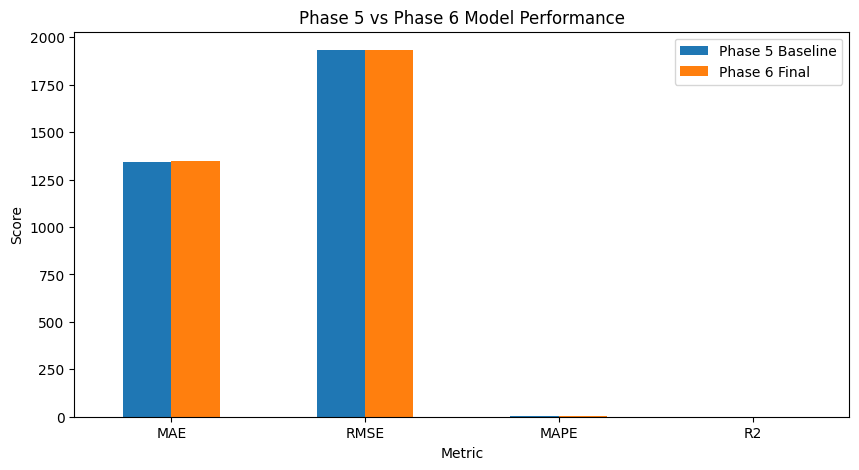

In [92]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Phase 5 vs Phase 6 Model Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [93]:
best_model.save(
    "final_BI_LSTM_forecasting_model.keras"
)

In [94]:
final_results.to_csv(
    "phase6_model_improvement_results.csv",
    index=False
)

In [95]:
comparison.to_csv(
    "phase5_vs_phase6_comparison.csv",
    index=False
)